## 1. Carga de datos

Cargamos los archivos CSV de cada compresor en un diccionario `data`,
donde cada clave es el nombre del compresor y el valor es su DataFrame.

Cada CSV contiene las columnas:
- **Presion**: presión atmosférica en la planta
- **Temperatura**: temperatura ambiente en la planta
- **Frecuencia**: frecuencia de operación del compresor
- **Potencia_Medida**: potencia real medida *(target)*
- **Potencia_Estimada**: estimación lineal del fabricante *(baseline)*

In [ ]:
import os
import pygad

import pandas as pd
import numpy as np
from joblib import Parallel, delayed
from itertools import product

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

c:\Users\ander\.conda\envs\RETO_07_PBD\Lib\site-packages\sklearn\utils\__init__.py:15: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.3)
  from scipy.sparse import issparse


In [2]:
ruta_base = "Datos/Originales"
archivos = ["CompA.csv", "CompB.csv", "CompC.csv", "CompD.csv"]
data = {}

for archivo in archivos:
    ruta_completa = os.path.join(ruta_base, archivo)
    nombre = archivo.replace(".csv", "")
    data[nombre] = pd.read_csv(ruta_completa)

print(data["CompA"].head())

    Presion  Temperatura  Frecuencia  Potencia_Medida  Potencia_Estimada
0  0.775748         16.9         0.0        71.466562          77.432556
1  0.776315         16.6         0.0        71.442768          77.498194
2  0.776784         16.6         0.0        71.347653          77.477151
3  0.777093         16.4         0.0        71.244807          77.524010
4  0.777436         16.4         0.0        71.194101          77.508609


In [3]:
for nombre, df in data.items():
    df.drop_duplicates(inplace=True)
    
    df = df[df["Frecuencia"] >= 0]
    df = df[df["Frecuencia"] <= 100]
    
    data[nombre] = df

## 2. Entrenamiento de modelos de regresión

Para predecir el consumo real de cada compresor usamos datos históricos medidos en planta.
Entrenamos un modelo de regresión por compresor con las variables `Presion`, `Temperatura` y `Frecuencia` como entrada y `Potencia_Medida` como target.

Comparamos tres modelos:
- **RandomForest**: captura relaciones no lineales entre variables
- **GradientBoosting**: similar a RandomForest pero entrena de forma secuencial, corrigiendo errores
- **Ridge**: regresión lineal regularizada, útil como baseline para comparar con los modelos no lineales

Para evaluar la calidad de cada modelo usamos **validación cruzada con 3 folds**, que nos da el **R²** medio y su desviación estándar (±).
Un R² cercano a 1 indica que el modelo predice bien. El mejor modelo por compresor se selecciona automáticamente.

In [4]:
def get_modelos_candidatos():
    return {
        "RandomForest":       RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1),
        "GradientBoosting":   GradientBoostingRegressor(n_estimators=10, random_state=42),
        "Ridge":              Pipeline([("scaler", StandardScaler()), ("ridge", Ridge())]),
    }

def entrenar_y_evaluar(nombre_comp, df, nombre_modelo, modelo):
    X = df[["Presion", "Temperatura", "Frecuencia"]]
    y = df["Potencia_Medida"]
    modelo.fit(X, y)
    scores = cross_val_score(modelo, X, y, cv=5, scoring="r2", n_jobs=-1)
    return nombre_comp, nombre_modelo, modelo, np.mean(scores), np.std(scores)

tareas = [
    (nombre_comp, df, nombre_modelo, modelo)
    for nombre_comp, df in data.items()
    for nombre_modelo, modelo in get_modelos_candidatos().items()
]

resultados_modelos = Parallel(n_jobs=-1)(
    delayed(entrenar_y_evaluar)(*t) for t in tareas
)

rows = []
for nombre_comp, nombre_modelo, _, r2_mean, r2_std in resultados_modelos:
    rows.append({"Compresor": nombre_comp, "Modelo": nombre_modelo,
                 "R2_medio": round(r2_mean, 4), "R2_std": round(r2_std, 4)})

df_r2 = pd.DataFrame(rows).sort_values(["Compresor", "R2_medio"], ascending=[True, False])
print("\n=== R² por compresor y modelo ===")
print(df_r2.to_string(index=False))

modelos = {}
for nombre_comp in data.keys():
    candidatos = [(r2, mod, nm) for (nc, nm, mod, r2, _) in resultados_modelos if nc == nombre_comp]
    best_r2, best_mod, best_name = max(candidatos, key=lambda x: x[0])
    modelos[nombre_comp] = best_mod
    print(f"{nombre_comp} → mejor modelo: {best_name} (R²={best_r2:.4f})")


=== R² por compresor y modelo ===
Compresor           Modelo  R2_medio  R2_std
    CompA     RandomForest    0.9592  0.0219
    CompA            Ridge    0.9387  0.0287
    CompA GradientBoosting    0.8346  0.0234
    CompB     RandomForest    0.9876  0.0029
    CompB            Ridge    0.9612  0.0058
    CompB GradientBoosting    0.8495  0.0206
    CompC     RandomForest    0.9852  0.0027
    CompC            Ridge    0.9544  0.0083
    CompC GradientBoosting    0.8459  0.0089
    CompD     RandomForest    0.9874  0.0016
    CompD            Ridge    0.9611  0.0105
    CompD GradientBoosting    0.8469  0.0173
CompA → mejor modelo: RandomForest (R²=0.9592)
CompB → mejor modelo: RandomForest (R²=0.9876)
CompC → mejor modelo: RandomForest (R²=0.9852)
CompD → mejor modelo: RandomForest (R²=0.9874)


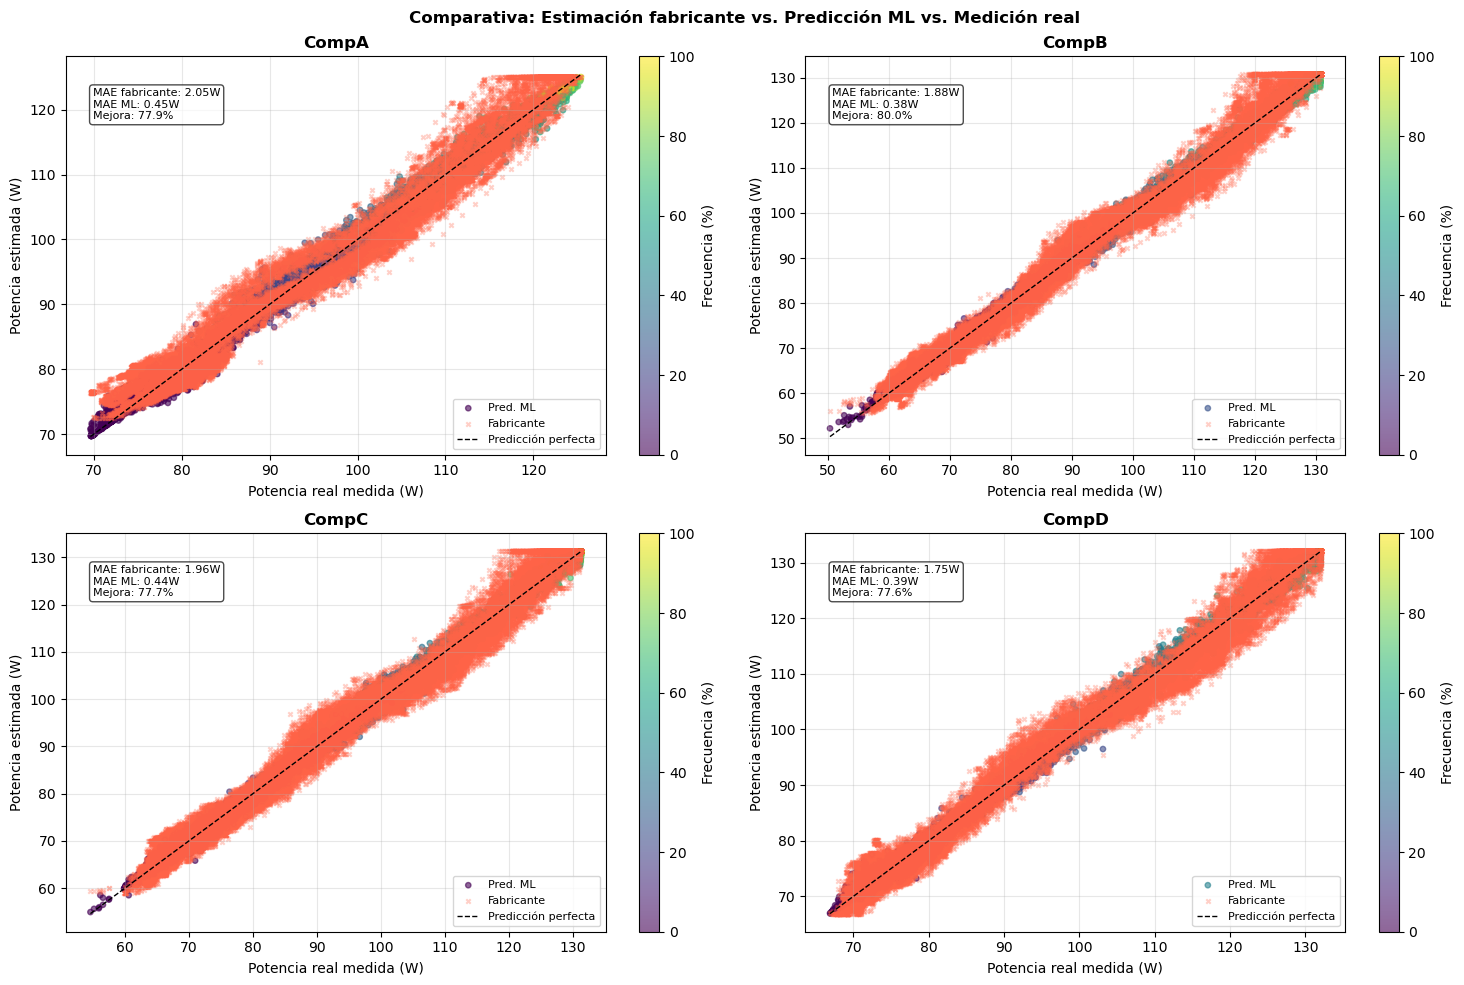


=== COMPARATIVA NOMINAL vs. REAL ===
Compresor  MAE_Fabricante  MAE_ML  Mejora_%
    CompA           2.051   0.453      77.9
    CompB           1.884   0.377      80.0
    CompC           1.962   0.438      77.7
    CompD           1.754   0.393      77.6

Mejora media del ML sobre el fabricante: 78.3%


In [ ]:
def plot_comparativa_nominal_real(data, modelos, nombres):
    """
    Para cada compresor, compara:
      - Potencia_Estimada (baseline fabricante)
      - Potencia_Medida   (dato real)
      - Predicción ML     (tu modelo)
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    resumen = []

    for idx, comp in enumerate(nombres):
        df  = data[comp].copy().reset_index(drop=True)
        X   = df[["Presion", "Temperatura", "Frecuencia"]]
        
        df["Pred_ML"] = modelos[comp].predict(X)

        mae_fabricante = (df["Potencia_Estimada"] - df["Potencia_Medida"]).abs().mean()
        mae_ml         = (df["Pred_ML"]           - df["Potencia_Medida"]).abs().mean()
        mejora_pct     = (mae_fabricante - mae_ml) / mae_fabricante * 100

        resumen.append({
            "Compresor":       comp,
            "MAE_Fabricante":  round(mae_fabricante, 3),
            "MAE_ML":          round(mae_ml, 3),
            "Mejora_%":        round(mejora_pct, 1),
        })

        ax = axes[idx]
        sc = ax.scatter(df["Potencia_Medida"], df["Pred_ML"],
                        c=df["Frecuencia"], cmap="viridis",
                        alpha=0.6, s=15, label="Pred. ML")
        ax.scatter(df["Potencia_Medida"], df["Potencia_Estimada"],
                   color="tomato", alpha=0.3, s=10, marker="x", label="Fabricante")

        lim = [df["Potencia_Medida"].min(), df["Potencia_Medida"].max()]
        ax.plot(lim, lim, "k--", linewidth=1, label="Predicción perfecta")

        plt.colorbar(sc, ax=ax, label="Frecuencia (%)")
        ax.set_xlabel("Potencia real medida (W)")
        ax.set_ylabel("Potencia estimada (W)")
        ax.set_title(comp, fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        ax.text(0.05, 0.92, f"MAE fabricante: {mae_fabricante:.2f}W\nMAE ML: {mae_ml:.2f}W\nMejora: {mejora_pct:.1f}%",
                transform=ax.transAxes, fontsize=8,
                verticalalignment="top",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

    plt.suptitle("Comparativa: Estimación fabricante vs. Predicción ML vs. Medición real",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    df_resumen = pd.DataFrame(resumen)
    print("\n=== COMPARATIVA NOMINAL vs. REAL ===")
    print(df_resumen.to_string(index=False))
    print(f"\nMejora media del ML sobre el fabricante: {df_resumen['Mejora_%'].mean():.1f}%")
    return df_resumen

nombres   = ["CompA", "CompB", "CompC", "CompD"]
df_comparativa = plot_comparativa_nominal_real(data, modelos, nombres)

## 3. Configuración del algoritmo genético y ejecución

### 3.1 Representación del individuo y función objetivo

Cada individuo es un vector de 4 genes, uno por compresor:

`[freq_CompA, freq_CompB, freq_CompC, freq_CompD]`

donde cada frecuencia es un valor continuo entre **5% y 100%**.

La **función objetivo** minimiza el consumo energético total predicho por los modelos ML,
penalizando las soluciones que incumplan las restricciones del problema:

| Restricción | Penalización |
|---|---|
| Caudal total < objetivo | 1000 × déficit de caudal |
| Frecuencia > 90% | 500 × exceso por compresor |
| Frecuencia < 5% | 500 por compresor |
| Cambio de configuración | 3W por actuador modificado |

### 3.2 Configuraciones GA comparadas

Se comparan **5 variantes** del algoritmo genético, combinando distintas estrategias de selección, cruce y mutación:

| Config | Selección | Cruce | Mutación | Generaciones |
|---|---|---|---|---|
| GA_base | sss | single_point | 1 gen | 30 |
| GA_uniform | tournament | uniform | 2 genes | 40 |
| GA_rank | rank | two_points | 1 gen | 35 |
| GA_rws | rws | scattered | 2 genes | 35 |
| GA_sus | sus | uniform | 1 gen | 40 |

Todas las configuraciones incluyen **elitismo** (se conservan los mejores individuos entre generaciones)
y un **early stop** que detiene la ejecución cuando la mejora del fitness es inferior a 0.5W durante varias generaciones consecutivas.

### 3.3 Casos de simulación

Se simulan **4 escenarios realistas** que cubren distintas condiciones de operación:

| Caso | Temperatura | Presión | Caudal objetivo |
|---|---|---|---|
| Caso1_normal | 16.5 °C | 0.78 atm | 250 l/s |
| Caso2_calor | 30.0 °C | 0.80 atm | 320 l/s |
| Caso3_frio | 5.0 °C | 0.75 atm | 150 l/s |
| Caso4_maximo | 35.0 °C | 0.82 atm | 380 l/s |

Cada caso parte de unas **frecuencias previas** distintas, ya que el coste de cambiar la configuración depende de cuántos actuadores se modifican respecto al estado anterior.

In [19]:
configs_ga = {

    "GA_base": dict(
        num_generations=30,
        sol_per_pop=20,
        num_parents_mating=4,
        crossover_type="single_point",
        crossover_probability=0.8,
        mutation_type="random",
        mutation_num_genes=1,
        keep_elitism=2,
        keep_parents=1,
        parent_selection_type="sss",
        stop_criteria="saturate_10",
    ),

    "GA_uniform": dict(
        num_generations=40,
        sol_per_pop=25,
        num_parents_mating=6,
        crossover_type="uniform",
        crossover_probability=0.9,
        mutation_type="random",
        mutation_num_genes=2,
        keep_elitism=2,
        keep_parents=2,
        parent_selection_type="tournament",
        stop_criteria="saturate_10",
    ),

    "GA_rank": dict(
        num_generations=35,
        sol_per_pop=20,
        num_parents_mating=4,
        crossover_type="two_points",
        crossover_probability=0.8,
        mutation_type="random",
        mutation_num_genes=1,
        keep_elitism=1,
        keep_parents=1,
        parent_selection_type="rank",
        stop_criteria="saturate_8",
    ),

    "GA_rws": dict(
        num_generations=35,
        sol_per_pop=20,
        num_parents_mating=5,
        crossover_type="scattered",
        crossover_probability=0.7,
        mutation_type="random",
        mutation_num_genes=2,
        keep_elitism=2,
        keep_parents=0,
        parent_selection_type="rws",
        stop_criteria="saturate_8",
    ),

    "GA_sus": dict(
        num_generations=40,
        sol_per_pop=25,
        num_parents_mating=6,
        crossover_type="uniform",
        crossover_probability=0.6,
        mutation_type="random",
        mutation_num_genes=1,
        keep_elitism=2,
        keep_parents=1,
        parent_selection_type="sus",
        stop_criteria="saturate_12",
    ),
}

In [ ]:
casos = [
    {"nombre": "Caso1_normal",    "P": 0.78, "T": 16.5, "caudal_objetivo": 250, "freqs_previas": {"CompA":50,"CompB":50,"CompC":50,"CompD":50}},
    {"nombre": "Caso2_calor",     "P": 0.80, "T": 30.0, "caudal_objetivo": 320, "freqs_previas": {"CompA":70,"CompB":60,"CompC":65,"CompD":70}},
    {"nombre": "Caso3_frio",      "P": 0.75, "T":  5.0, "caudal_objetivo": 150, "freqs_previas": {"CompA":30,"CompB":30,"CompC":30,"CompD":30}},
    {"nombre": "Caso4_maximo",    "P": 0.82, "T": 35.0, "caudal_objetivo": 380, "freqs_previas": {"CompA":80,"CompB":80,"CompC":80,"CompD":80}},
]

caudales = {"CompA": 100, "CompB": 90, "CompC": 95, "CompD": 110}
nombres   = ["CompA", "CompB", "CompC", "CompD"]

In [25]:
historial_fitness = {}  

def correr_experimento(caso, nombre_config, config):
    P             = caso["P"]
    T             = caso["T"]
    caudal_obj    = caso["caudal_objetivo"]
    freqs_previas = caso["freqs_previas"]

    umbral_consumo   = 0.5  
    ventana_gens     = 8    
    historial_consumo = []  
    fitness_por_gen   = []

    def fitness_func(ga_instance, solution, solution_idx):
        freqs = dict(zip(nombres, solution))
        consumo_total = sum(
            modelos[comp].predict(
                pd.DataFrame([[P, T, freqs[comp]]],
                             columns=["Presion","Temperatura","Frecuencia"])
            )[0]
            for comp in nombres
        )
        cambios = sum(1 for c in nombres if abs(freqs[c] - freqs_previas[c]) > 0.01)
        consumo_total += cambios * 3

        penalizacion = 0
        caudal = sum((freqs[c] / 100) * caudales[c] for c in nombres)
        if caudal < caudal_obj:
            penalizacion += 1000 * (caudal_obj - caudal)
        for f in solution:
            if f > 90:
                penalizacion += 500 * (f - 90)
            if f < 5:
                penalizacion += 500

        return -(consumo_total + penalizacion)

    def on_generation(ga_instance):
        sol, fit, _ = ga_instance.best_solution()
        fitness_por_gen.append(-fit)
        freqs       = dict(zip(nombres, sol))
        caudal      = sum((freqs[c] / 100) * caudales[c] for c in nombres)

        if caudal >= caudal_obj:
            consumo = sum(
                modelos[comp].predict(
                    pd.DataFrame([[P, T, freqs[comp]]],
                                 columns=["Presion","Temperatura","Frecuencia"])
                )[0]
                for comp in nombres
            )
            historial_consumo.append(consumo)

            if len(historial_consumo) >= ventana_gens:
                mejora = historial_consumo[-ventana_gens] - historial_consumo[-1]
                if mejora < umbral_consumo:
                    gen = ga_instance.generations_completed
                    print(f"    [Early stop] gen {gen} — mejora {mejora:.3f}W < {umbral_consumo}W")
                    return "stop"
        else:
            historial_consumo.clear()

    ga = pygad.GA(
        **config,
        fitness_func=fitness_func,
        on_generation=on_generation,  
        num_genes=4,
        gene_space=[{"low": 5, "high": 100}] * 4,
        suppress_warnings=True,
    )
    ga.run()

    historial_fitness[(caso["nombre"], nombre_config)] = fitness_por_gen

    sol, fit, _ = ga.best_solution()
    freqs_opt   = dict(zip(nombres, sol))
    caudal      = sum((freqs_opt[c] / 100) * caudales[c] for c in nombres)
    consumo     = 0
    for comp in nombres:
        entrada = pd.DataFrame([[P, T, freqs_opt[comp]]],
                               columns=["Presion", "Temperatura", "Frecuencia"])
        consumo += modelos[comp].predict(entrada)[0]

    return {
        "Caso":          caso["nombre"],
        "Config_GA":     nombre_config,
        "Fitness":       round(-fit, 2),
        "Consumo_W":     round(consumo, 2),
        "Caudal_ls":     round(caudal, 2),
        "Objetivo_ls":   caudal_obj,
        "Cumple":        "✓" if caudal >= caudal_obj else "✗",
        **{f"Freq_{c}": round(freqs_opt[c], 1) for c in nombres},
    }

resultados_ga = []
for caso in casos:
    for nombre_config, config in configs_ga.items():
        print(f"  Corriendo {caso['nombre']} con {nombre_config}...")
        res = correr_experimento(caso, nombre_config, config)
        resultados_ga.append(res)


  Corriendo Caso1_normal con GA_base...
    [Early stop] gen 9 — mejora 0.000W < 0.5W
  Corriendo Caso1_normal con GA_uniform...
    [Early stop] gen 11 — mejora 0.000W < 0.5W
  Corriendo Caso1_normal con GA_rank...
    [Early stop] gen 8 — mejora 0.000W < 0.5W
  Corriendo Caso1_normal con GA_rws...
    [Early stop] gen 18 — mejora 0.000W < 0.5W
  Corriendo Caso1_normal con GA_sus...
    [Early stop] gen 8 — mejora 0.000W < 0.5W
  Corriendo Caso2_calor con GA_base...
    [Early stop] gen 8 — mejora 0.000W < 0.5W
  Corriendo Caso2_calor con GA_uniform...
    [Early stop] gen 18 — mejora 0.000W < 0.5W
  Corriendo Caso2_calor con GA_rank...
    [Early stop] gen 8 — mejora -5.272W < 0.5W
  Corriendo Caso2_calor con GA_rws...
  Corriendo Caso2_calor con GA_sus...
  Corriendo Caso3_frio con GA_base...
    [Early stop] gen 16 — mejora 0.000W < 0.5W
  Corriendo Caso3_frio con GA_uniform...
    [Early stop] gen 20 — mejora 0.000W < 0.5W
  Corriendo Caso3_frio con GA_rank...
    [Early stop] gen

In [26]:
df_res = pd.DataFrame(resultados_ga)
print("\n=== RESULTADOS COMPLETOS ===")
print(df_res[["Caso","Config_GA","Cumple","Caudal_ls","Objetivo_ls",
              "Consumo_W","Freq_CompA","Freq_CompB","Freq_CompC","Freq_CompD"]].to_string(index=False))

print("\n=== MEJOR CONFIG POR CASO (menor consumo que cumple) ===")
df_validos = df_res[df_res["Cumple"] == "✓"]
if not df_validos.empty:
    idx_mejor = df_validos.groupby("Caso")["Consumo_W"].idxmin()
    print(df_validos.loc[idx_mejor][["Caso","Config_GA","Consumo_W","Caudal_ls"]].to_string(index=False))
else:
    print("Ninguna configuración cumplió el caudal objetivo en todos los casos.")


=== RESULTADOS COMPLETOS ===
        Caso  Config_GA Cumple  Caudal_ls  Objetivo_ls  Consumo_W  Freq_CompA  Freq_CompB  Freq_CompC  Freq_CompD
Caso1_normal    GA_base      ✓     251.58          250     452.44        83.9        49.9        28.5        87.0
Caso1_normal GA_uniform      ✓     252.57          250     451.24        88.2         8.6        88.3        66.1
Caso1_normal    GA_rank      ✓     289.27          250     473.44        85.6        29.9        85.2        87.1
Caso1_normal     GA_rws      ✓     251.85          250     451.68        79.5         5.7        74.8        87.4
Caso1_normal     GA_sus      ✓     259.84          250     454.07        87.8        85.1         9.2        78.8
 Caso2_calor    GA_base      ✓     320.14          320     489.50        88.9        58.1        91.3        83.8
 Caso2_calor GA_uniform      ✓     327.34          320     492.68        89.9        79.1        84.5        78.2
 Caso2_calor    GA_rank      ✓     328.88          320    

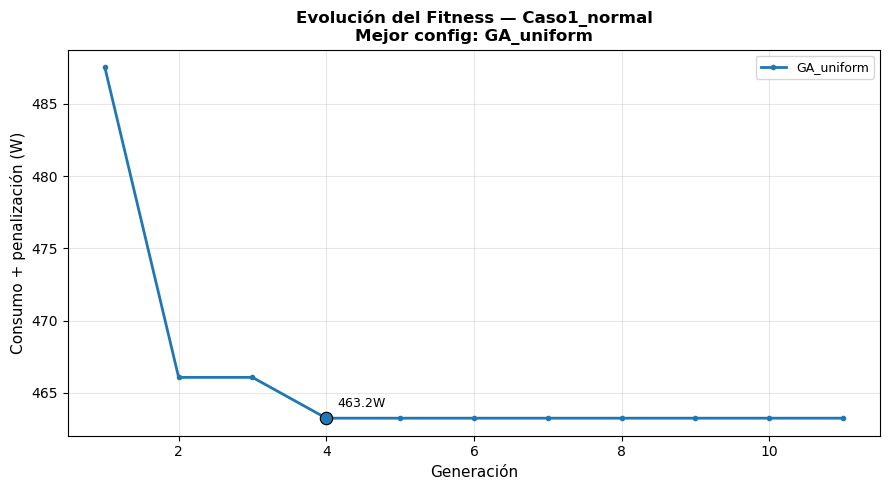

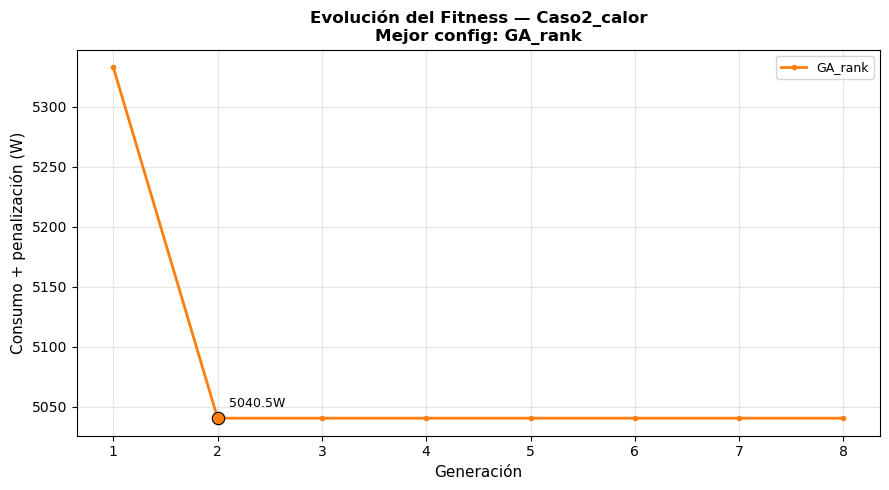

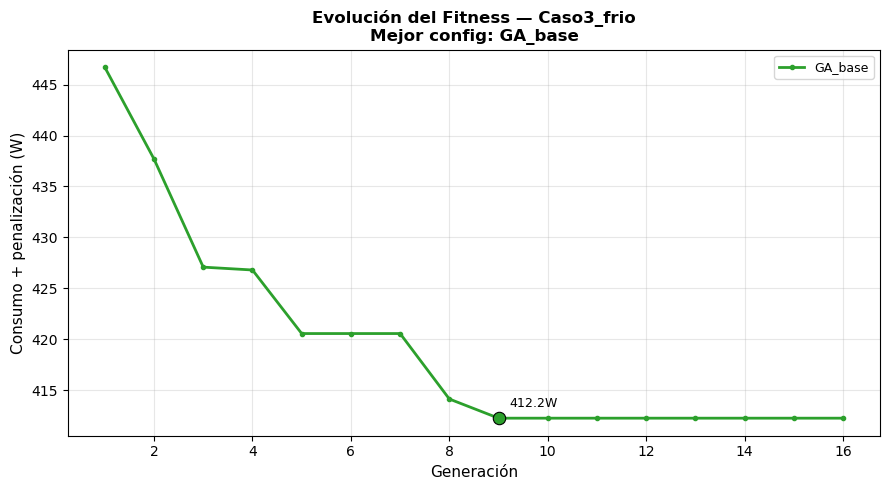

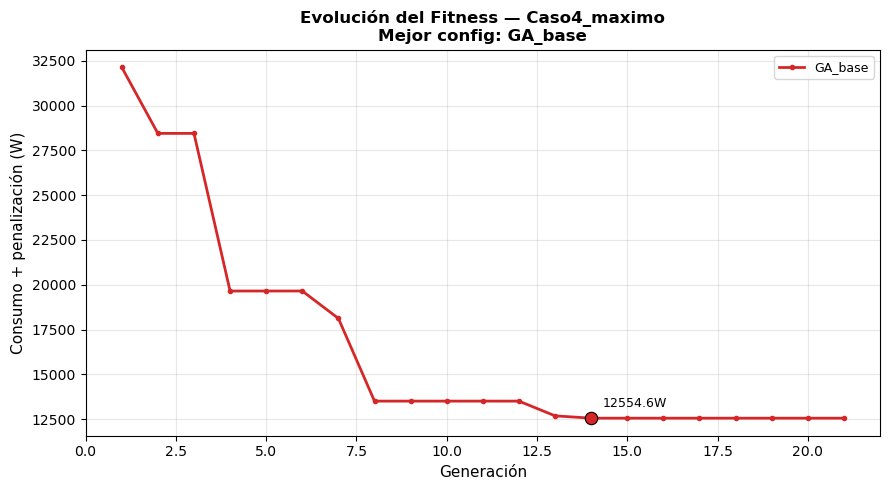

In [29]:
def plot_evolucion_fitness(historial_fitness, casos, df_res):
    colores = list(mcolors.TABLEAU_COLORS.values())

    # Mejor config por caso (menor consumo que cumple)
    df_validos = df_res[df_res["Cumple"] == "✓"]
    mejor_config_por_caso = df_validos.groupby("Caso")["Consumo_W"].idxmin()
    mejor_por_caso = df_validos.loc[mejor_config_por_caso].set_index("Caso")["Config_GA"].to_dict()

    for i, caso in enumerate(casos):
        nombre_caso   = caso["nombre"]
        mejor_config  = mejor_por_caso.get(nombre_caso)
        if mejor_config is None:
            print(f"  {nombre_caso}: ninguna config cumplió el caudal, se omite.")
            continue

        hist = historial_fitness.get((nombre_caso, mejor_config), [])
        if not hist:
            continue

        fig, ax = plt.subplots(figsize=(9, 5))
        gens = range(1, len(hist) + 1)
        ax.plot(gens, hist, color=colores[i % len(colores)], linewidth=2,
                marker="o", markersize=3, label=mejor_config)

        # Marca el mínimo
        idx_min = int(np.argmin(hist))
        ax.scatter(idx_min + 1, hist[idx_min], color=colores[i % len(colores)],
                   s=80, zorder=5, edgecolors="black", linewidths=0.8)
        ax.annotate(f"{hist[idx_min]:.1f}W",
                    xy=(idx_min + 1, hist[idx_min]),
                    xytext=(8, 8), textcoords="offset points", fontsize=9)

        ax.set_title(f"Evolución del Fitness — {nombre_caso}\nMejor config: {mejor_config}",
                     fontsize=12, fontweight="bold")
        ax.set_xlabel("Generación", fontsize=11)
        ax.set_ylabel("Consumo + penalización (W)", fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

plot_evolucion_fitness(historial_fitness, casos, df_res)

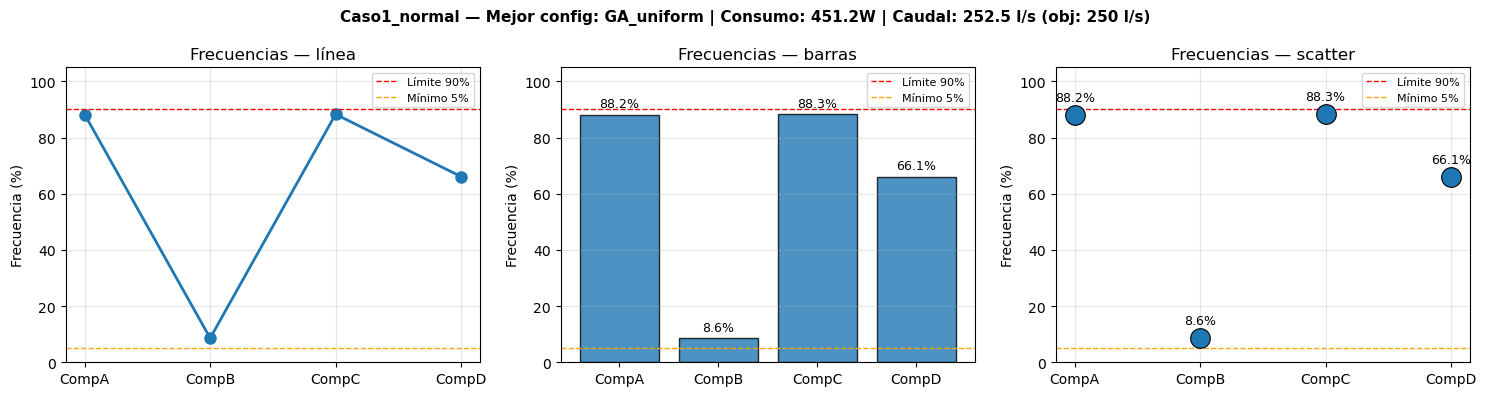

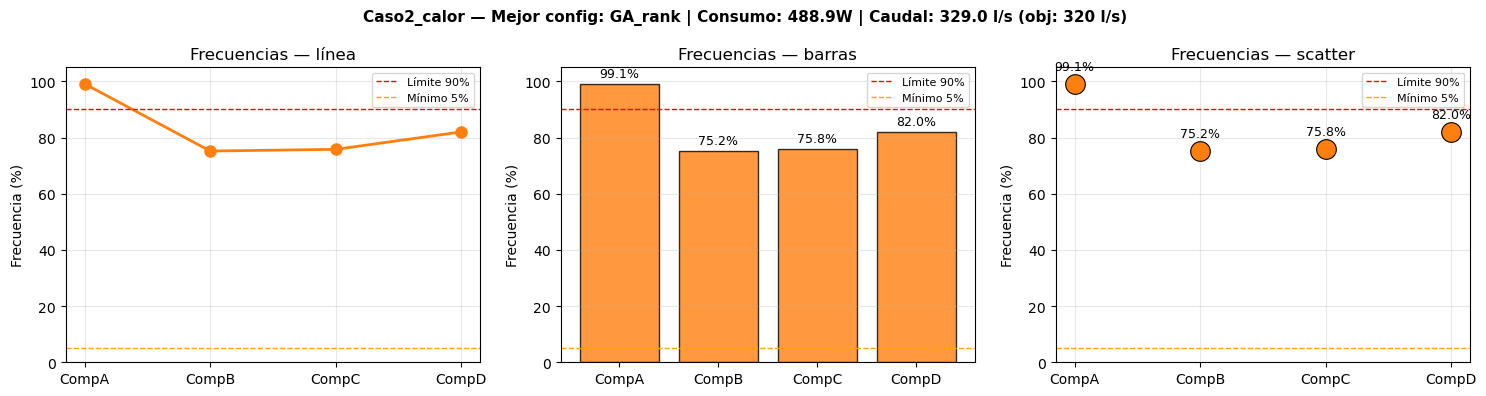

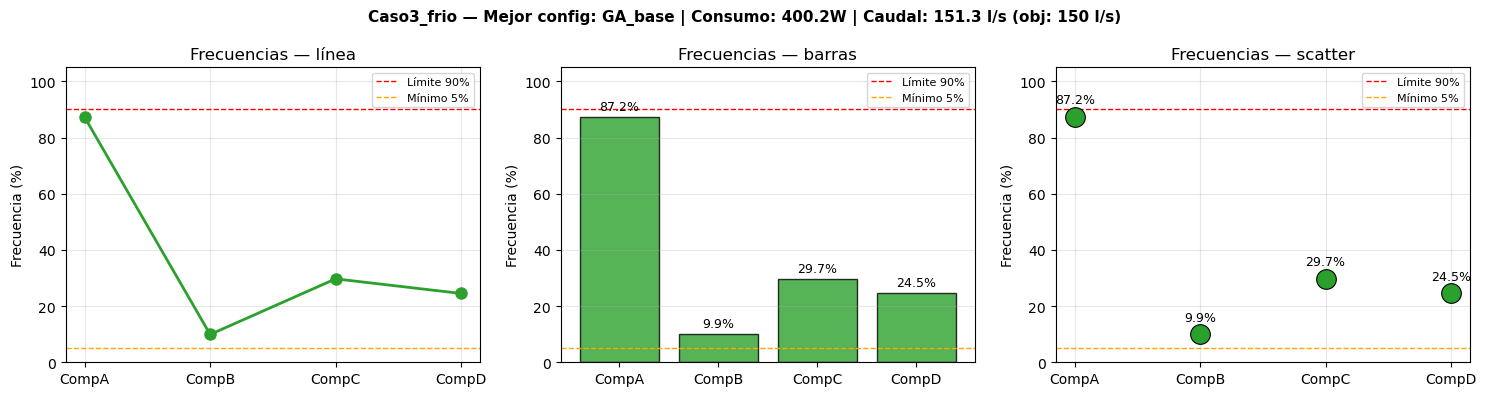

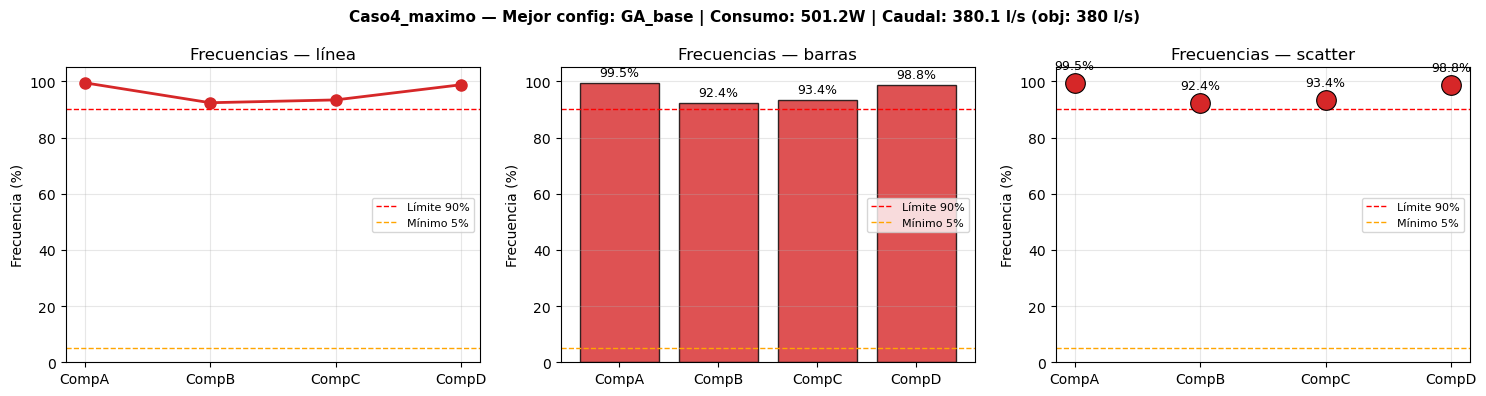

In [30]:
def plot_genes_mejor_solucion(historial_fitness, casos, df_res, modelos, caudales, nombres):
    colores = list(mcolors.TABLEAU_COLORS.values())

    # Mejor config por caso
    df_validos = df_res[df_res["Cumple"] == "✓"]
    mejor_por_caso = df_validos.loc[
        df_validos.groupby("Caso")["Consumo_W"].idxmin()
    ].set_index("Caso")

    for i, caso in enumerate(casos):
        nombre_caso = caso["nombre"]
        if nombre_caso not in mejor_por_caso.index:
            print(f"  {nombre_caso}: ninguna config cumplió el caudal, se omite.")
            continue

        fila = mejor_por_caso.loc[nombre_caso]
        freqs = [fila[f"Freq_{c}"] for c in nombres]

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        # ── Plot (línea) ──────────────────────────────────────────────────
        axes[0].plot(nombres, freqs, color=colores[i], linewidth=2,
                     marker="o", markersize=8)
        axes[0].axhline(90, color="red",    linestyle="--", linewidth=1, label="Límite 90%")
        axes[0].axhline(5,  color="orange", linestyle="--", linewidth=1, label="Mínimo 5%")
        axes[0].set_ylim(0, 105)
        axes[0].set_title("Frecuencias — línea")
        axes[0].set_ylabel("Frecuencia (%)")
        axes[0].legend(fontsize=8)
        axes[0].grid(True, alpha=0.3)

        # ── Bar (barras) ──────────────────────────────────────────────────
        bars = axes[1].bar(nombres, freqs, color=colores[i], alpha=0.8, edgecolor="black")
        axes[1].axhline(90, color="red",    linestyle="--", linewidth=1, label="Límite 90%")
        axes[1].axhline(5,  color="orange", linestyle="--", linewidth=1, label="Mínimo 5%")
        axes[1].set_ylim(0, 105)
        axes[1].set_title("Frecuencias — barras")
        axes[1].set_ylabel("Frecuencia (%)")
        axes[1].legend(fontsize=8)
        axes[1].grid(True, alpha=0.3, axis="y")
        for bar, freq in zip(bars, freqs):
            axes[1].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + 1.5,
                         f"{freq:.1f}%", ha="center", va="bottom", fontsize=9)

        # ── Scatter (dispersión) ──────────────────────────────────────────
        axes[2].scatter(nombres, freqs, color=colores[i], s=200,
                        zorder=5, edgecolors="black", linewidths=0.8)
        axes[2].axhline(90, color="red",    linestyle="--", linewidth=1, label="Límite 90%")
        axes[2].axhline(5,  color="orange", linestyle="--", linewidth=1, label="Mínimo 5%")
        for comp, freq in zip(nombres, freqs):
            axes[2].annotate(f"{freq:.1f}%", xy=(comp, freq),
                             xytext=(0, 10), textcoords="offset points",
                             ha="center", fontsize=9)
        axes[2].set_ylim(0, 105)
        axes[2].set_title("Frecuencias — scatter")
        axes[2].set_ylabel("Frecuencia (%)")
        axes[2].legend(fontsize=8)
        axes[2].grid(True, alpha=0.3)

        # Título global con info del caso
        caudal_real = sum((freqs[j] / 100) * caudales[nombres[j]] for j in range(4))
        fig.suptitle(
            f"{nombre_caso} — Mejor config: {fila['Config_GA']} | "
            f"Consumo: {fila['Consumo_W']:.1f}W | "
            f"Caudal: {caudal_real:.1f} l/s (obj: {caso['caudal_objetivo']} l/s)",
            fontsize=11, fontweight="bold"
        )

        plt.tight_layout()
        plt.show()

plot_genes_mejor_solucion(historial_fitness, casos, df_res, modelos, caudales, nombres)